# What are Hyper Parameters?
- Parameters = Learned from data such as weight, biases, etc.
- Hyperparameter = set manually before training; they control the learning process.

Examples;
1. Learning rate
2. batch size
3. Number of layers/neurons
4. Dropout rate
5. Optimizer type
6. Regularization strength
etc.

- Choosing the right hyperparameters == the distance between poor performance and state of the art result.

# What is Hyperparameter Tuning?
- The process of selecting the best value for the hyper parameter in order to get the best results in terms of performance, accuracy and all is hyperparameter tuning.


##### Why do we Need Hyper Parameter Tuning?
- Wrong Hyperparameters : Slow convergence, overfitting/underfitting, poor accuracy.
- Correct Hyperparameter : Faster training, bettter generalization, efficient use of resources.

### Key HyperParameters to Tune In Deep Learning Model Development.

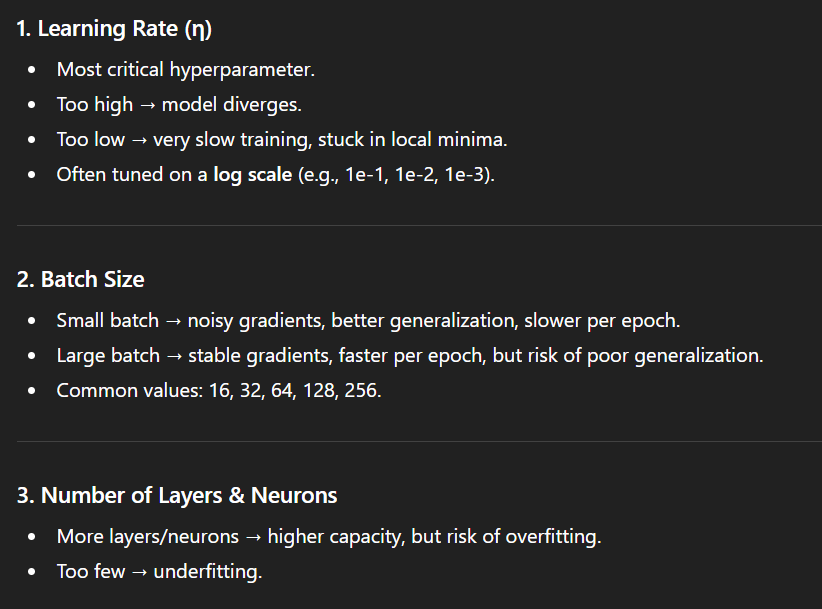
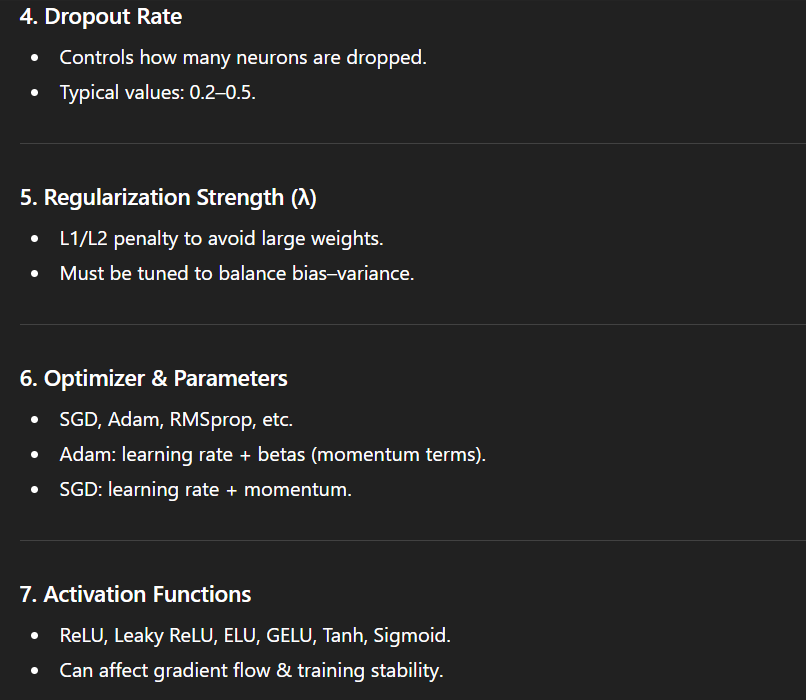
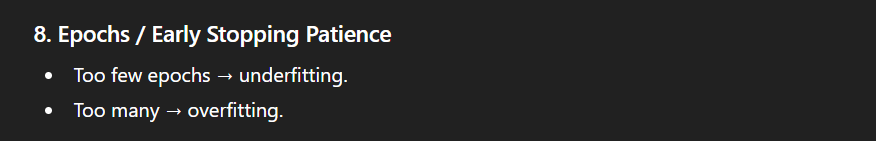
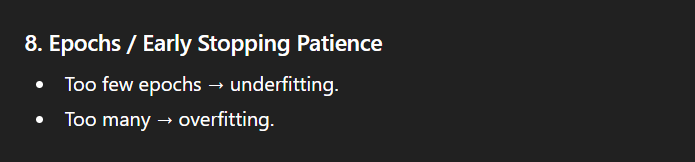

### Hyperparameter Tuning Methods

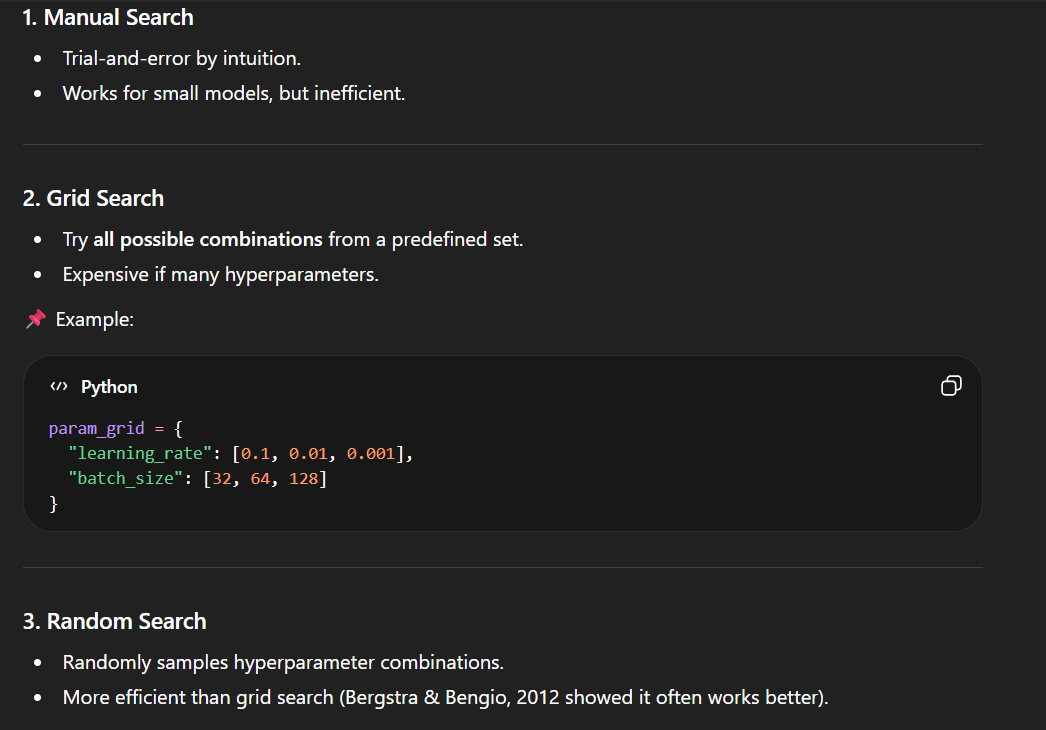
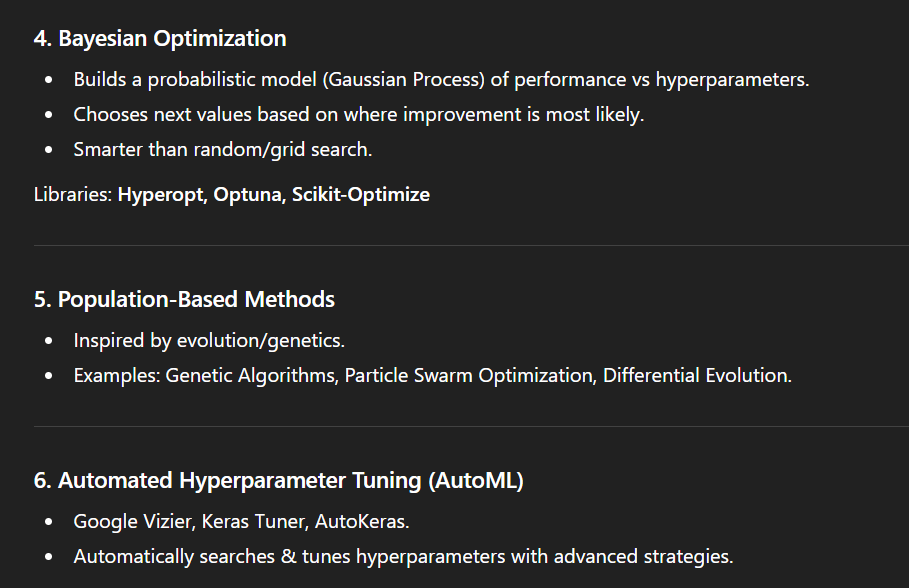

### Code Example

In [ ]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

# Define model builder function
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28,28)))

    # Tune number of units
    model.add(keras.layers.Dense(
        units=hp.Int("units", min_value=32, max_value=512, step=32),
        activation="relu"))
    
    # Tune dropout rate
    model.add(keras.layers.Dropout(hp.Float("dropout", 0.1, 0.5, step=0.1)))

    model.add(keras.layers.Dense(10, activation="softmax"))
    
    # Tune learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    
    return model

# Hyperparameter tuner
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=2,
    directory="my_dir",
    project_name="mnist_tuning")

# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

tuner.search(x_train, y_train, epochs=5, validation_split=0.2)